/tmp/ipykernel_20063/3577455602.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Topsis_Score', y='Model', data=df, palette='viridis')


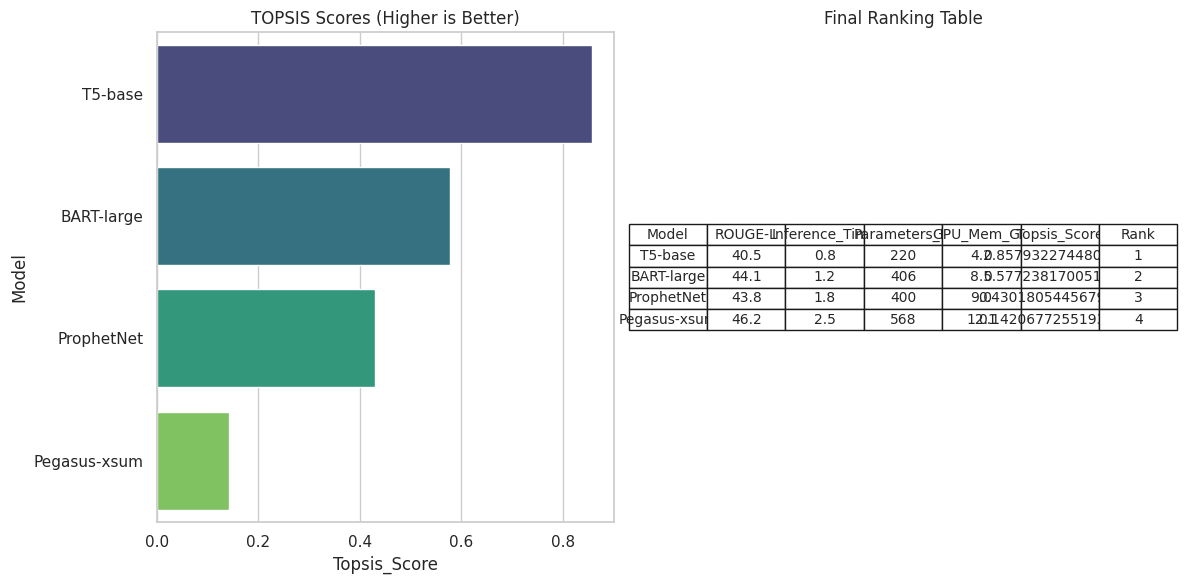

Results saved to topsis_results.csv
          Model  ROUGE-L  Inference_Time  Parameters_M  GPU_Mem_GB  \
1       T5-base     40.5             0.8           220         4.2   
0    BART-large     44.1             1.2           406         8.5   
3    ProphetNet     43.8             1.8           400         9.0   
2  Pegasus-xsum     46.2             2.5           568        12.1   

   Topsis_Score  Rank  
1      0.857932     1  
0      0.577238     2  
3      0.430181     3  
2      0.142068     4  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Model': ['BART-large', 'T5-base', 'Pegasus-xsum', 'ProphetNet'],
    'ROUGE-L': [44.1, 40.5, 46.2, 43.8],
    'Inference_Time': [1.2, 0.8, 2.5, 1.8],
    'Parameters_M': [406, 220, 568, 400],
    'GPU_Mem_GB': [8.5, 4.2, 12.1, 9.0]
}

df = pd.DataFrame(data)
matrix = df.iloc[:, 1:].values
weights = np.array([0.4, 0.2, 0.2, 0.2])
impacts = ['+', '-', '-', '-']

def topsis(matrix, weights, impacts):
    norm_matrix = matrix / np.sqrt(np.sum(matrix**2, axis=0))

    weighted_matrix = norm_matrix * weights

    best = []
    worst = []
    for i in range(len(impacts)):
        if impacts[i] == '+':
            best.append(np.max(weighted_matrix[:, i]))
            worst.append(np.min(weighted_matrix[:, i]))
        else:
            best.append(np.min(weighted_matrix[:, i]))
            worst.append(np.max(weighted_matrix[:, i]))

    dist_best = np.sqrt(np.sum((weighted_matrix - best)**2, axis=1))
    dist_worst = np.sqrt(np.sum((weighted_matrix - worst)**2, axis=1))

    scores = dist_worst / (dist_best + dist_worst)
    return scores

df['Topsis_Score'] = topsis(matrix, weights, impacts)
df['Rank'] = df['Topsis_Score'].rank(ascending=False).astype(int)
df = df.sort_values(by='Rank')

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Topsis_Score', y='Model', data=df, palette='viridis')
plt.title('TOPSIS Scores (Higher is Better)')

plt.subplot(1, 2, 2)
plt.axis('off')
table = plt.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.title('Final Ranking Table')

plt.tight_layout()
plt.show()

df.to_csv('topsis_results.csv', index=False)
print("Results saved to topsis_results.csv")
print(df)